In [1]:
# Import Packages
import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import numpy as np

In [2]:
# Define Constante
# We are Working with 3 Classes: (Fish, Lobster, Squid)
classes = ["Fish", "Lobster", "Squid"]

In [3]:
real_train_path = "/kaggle/input/datasets/mikoajfish99/marine-animal-images/images/train"
real_test_path ="/kaggle/input/datasets/mikoajfish99/marine-animal-images/images/test"

In [4]:
# Get Train Set URL
train_set_urls = {}
for class_name in classes:
    train_set_urls[class_name] = []

for folder_name in os.listdir(real_train_path):
    if (folder_name in classes):
        path = f"{real_train_path}/{folder_name}"
        print(path)
        for file_name in os.listdir(path):
            train_set_urls[folder_name].append(f"{path}/{file_name}")


/kaggle/input/datasets/mikoajfish99/marine-animal-images/images/train/Lobster
/kaggle/input/datasets/mikoajfish99/marine-animal-images/images/train/Squid
/kaggle/input/datasets/mikoajfish99/marine-animal-images/images/train/Fish


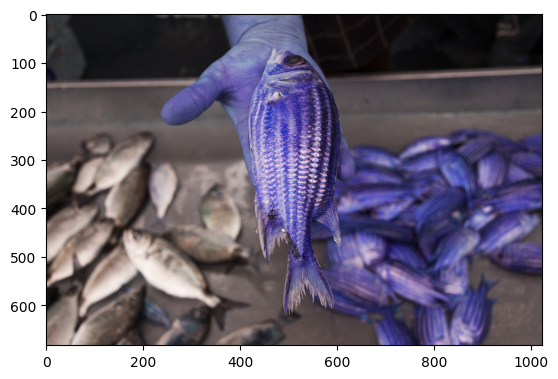

In [5]:
img = cv2.imread(train_set_urls["Fish"][3])
plt.imshow(img)

In [6]:
# Get Test Set URL
test_set_urls = {}
for class_name in classes:
    test_set_urls[class_name] = []

test_set_urls = {}
for class_name in classes:
    test_set_urls[class_name] = []

for folder_name in os.listdir(real_test_path):
    if (folder_name in classes):
        path = f"{real_test_path}/{folder_name}"
        print(path)
        for file_name in os.listdir(path):
            test_set_urls[folder_name].append(f"{path}/{file_name}")


/kaggle/input/datasets/mikoajfish99/marine-animal-images/images/test/Lobster
/kaggle/input/datasets/mikoajfish99/marine-animal-images/images/test/Squid
/kaggle/input/datasets/mikoajfish99/marine-animal-images/images/test/Fish


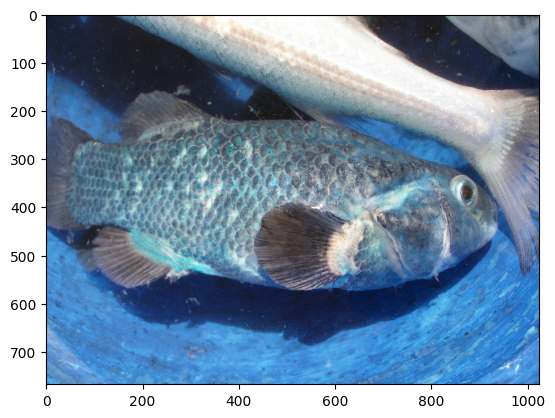

In [7]:
img = cv2.imread(test_set_urls["Fish"][0])
plt.imshow(img)

In [8]:
from skimage.feature import SIFT
from PIL import Image

In [9]:
# Feature Extraction With SIFT
des_list = [] # (img_path/img.png, array of descriptors)
sift = cv2.SIFT_create()

count = 0
nbr_image = 0
for class_name in classes:
    images = train_set_urls[class_name]
    for img in images:
        # convert image in array
        img_arr = np.array(Image.open(img))

        # get descriptor for image
        keypoints, descriptors = sift.detectAndCompute(img_arr, None)
        if descriptors is not None:
            des_list.append((f"{class_name}/{img}", descriptors))
        count += len(descriptors)
        nbr_image += 1

In [10]:
print(f"Number of Image is {nbr_image}")
print(f"Total Number of Descriptors is {count}")

Number of Image is 177
Total Number of Descriptors is 584243


In [11]:
# Convert Descriptors in 2D
all_descriptors = np.vstack([dest for path, dest in des_list])
print(f"Shape finale : {all_descriptors.shape}")

Shape finale : (584243, 128)


In [12]:
# Bag Of Features Creation
# Why We Need Bag Of Features: Because Eash Image has Specific Number Of Features
# Gaol With Kmeans is:
# Fish/img1   → (50, 128)  →  histogramme → [0, 3, 0, 1, 2, ...]  taille 200
# in cluster 1 there 3 descriptors
# Eash Image has one vector of 200 elements


In [13]:
# Import KMeans
from sklearn.cluster import KMeans

In [14]:
# Define KMeans Model
k = 200
kmeans = KMeans(n_clusters=k)

In [15]:
kmeans.fit(all_descriptors)
# in This Kmeans Contain 200 Cluster:
# cluster 5 has :
#   - keypoint of Fish/img1
#   - keypoint of Shark/img3
#   - keypoint of Fish/img7
#   - keypoint of Dolphin/img2

KMeans(n_clusters=200)

In [16]:
# Get Centers for Eash Clusters
codebook = kmeans.cluster_centers_
print(len(codebook[0])) # center of cluster in 128 dimention

128


In [17]:
# Get Features for Each Descriptor
# Create 2d of number of image and each element contain 200 values
im_features = np.zeros((len(des_list), k), "float32") 

for i, (img_path, descriptors) in enumerate(des_list):
    words = kmeans.predict(descriptors) # for eash keypoint in wich cluster exit
    print("number of clusters: ", len(words), words[0])
    # words = [0, 93, 30, , ..., 39]: 39 means last descriptor exit in cluster 39
    for w in words:
        # we take im_features[0][39] += 1 --> means cluster 39 contain one descritor
        im_features[i][w] += 1 # for first image assing array of 200 value

number of clusters:  2541 89
number of clusters:  2822 151
number of clusters:  901 26
number of clusters:  1754 153
number of clusters:  2012 110
number of clusters:  13046 141
number of clusters:  829 161
number of clusters:  3241 172
number of clusters:  3684 98
number of clusters:  10458 59
number of clusters:  2092 68
number of clusters:  2122 146
number of clusters:  155 138
number of clusters:  4712 6
number of clusters:  67 66
number of clusters:  3693 14
number of clusters:  2444 139
number of clusters:  2715 8
number of clusters:  785 94
number of clusters:  888 45
number of clusters:  11444 174
number of clusters:  3383 187
number of clusters:  3778 149
number of clusters:  2498 187
number of clusters:  342 145
number of clusters:  8166 174
number of clusters:  3983 150
number of clusters:  1340 188
number of clusters:  1917 52
number of clusters:  5689 37
number of clusters:  4170 122
number of clusters:  888 163
number of clusters:  3186 77
number of clusters:  3794 94
num

In [18]:
# Display Informations
print(len(im_features)) # number of image
print(len(im_features[0])) # first image represented by vector of 200 values
# [0, 10, 29 ...] --> 10 means cluster number 1 contain 10 descriptor are the same

177
200


In [19]:
# Import Packages
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler

In [20]:
# 1. Build labels
image_classes = []
for class_id, class_name in enumerate(classes):
    print(class_name, class_id)
    image_classes += [class_id] * len(train_set_urls[class_name])

print(image_classes)

Fish 0
Lobster 1
Squid 2
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [21]:
# 2. Normalisation
stdSlr = StandardScaler().fit(im_features)
im_features_scaled = stdSlr.transform(im_features)

In [22]:
# 3. Train SVM
clf = LinearSVC(max_iter=10000)
clf.fit(im_features_scaled, np.array(image_classes))
print("SVM trained ✅")

SVM trained ✅


number of descriptors:  3507
3507.0


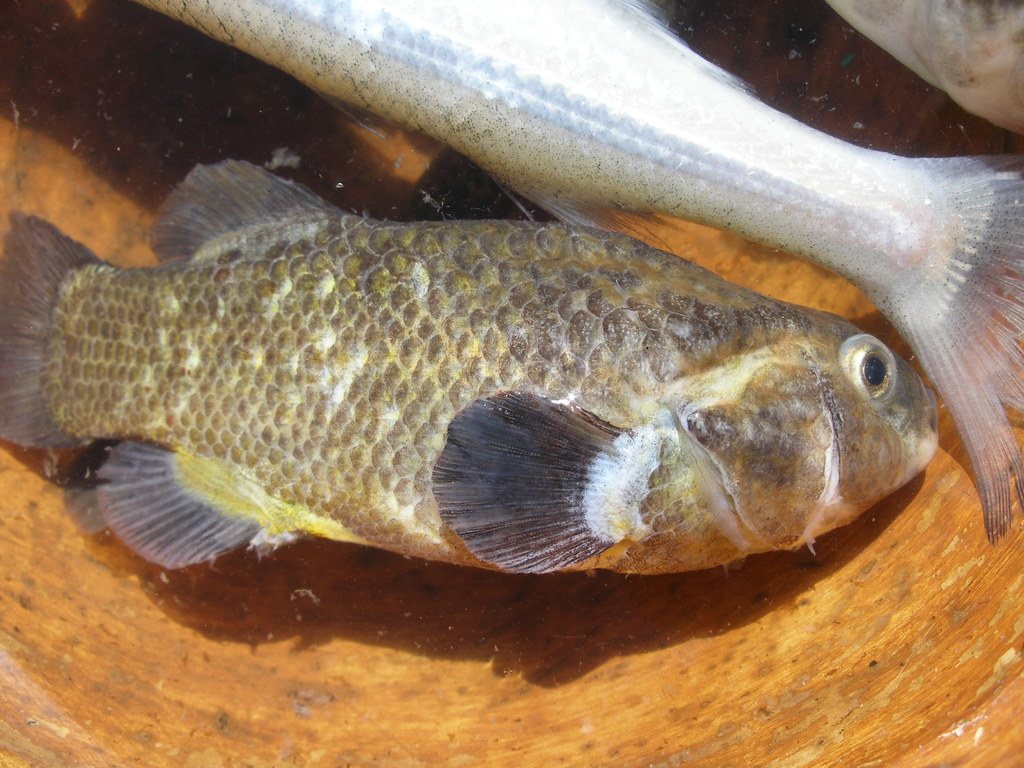

In [23]:
# Know L'ets Predit With SVM
# PipeLIne for Predction
# Image --> Get Descriptor --> Get Clusters --> SVM gonna Predict

# Get Image Path
test_image_path = test_set_urls["Fish"][0]
# Open The Image
img = Image.open(test_image_path)
img_arr = np.array(img)

# Get Image Descriptors
keypoints, descriptors = sift.detectAndCompute(img_arr, None)
print("number of descriptors: ", len(descriptors))
# Get KMeans Clusters
words = kmeans.predict(descriptors)

# Get Image Features
im_features = np.zeros((1, k), "float32")
for w in words:
    im_features[0][w] += 1
print(sum(im_features[0]))

# Normalisation
im_features_normlised = stdSlr.transform(im_features)

# Predict The Class With SVM
clf.predict(im_features_normlised) # Predict 0 --> Means is Fish

# Display Image
img